# Analysis Notebook for Live Fly Experiments

## Imports

In [538]:
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle
from matplotlib.colors import CenteredNorm 
import numpy as np
import pandas as pd
import pingouin


from unityvr.preproc import logproc as lp
from unityvr.analysis import posAnalysis, align2img
from gulp2p import utils as utils
from gulp2p import ImagingPreProc as iPP
from gulp2p import ROIs as ROIs

## Select data

In [539]:
OUTPUT_FOLDER = Path(r"C:\Users\ahshenas\Desktop\live fly analysis")

In [540]:

expt_pickle = Path(utils.loadFileNames(single_file=True, title="Select pickled experiment data"))

## Load data

In [541]:
# Load synced df pickle
with open(expt_pickle, 'rb') as pkl:
    exptDat = pickle.load(pkl)
expDf = exptDat['expDf']

## Functions

In [542]:
def get_num_rois(df):
    count = 0
    for col in df.columns:
        if (col[:3] == "roi"):
            count += 1
    return count

In [543]:
def shift_elements(arr, num, fill_value=np.nan):
    arr = np.roll(arr,num)
    if num < 0:
        arr[num:] = fill_value
    elif num > 0:
        arr[:num] = fill_value
    return arr

def correlate_with_lag(a, v, lags):
    corrs = []
    for lag in lags:
        # Lag second array
        if lag < 0:
            lagged_a = a[:lag]
            lagged_v = v[-lag:]
        elif lag == 0:
            lagged_a = a
            lagged_v = v
        else:
            lagged_a = a[lag:]
            lagged_v = v[:-lag]

        corr = np.corrcoef(lagged_a, lagged_v)[0,1]
        corrs.append(corr)

    return corrs

In [544]:
# ['trialName', 'fpv', 'meanMIP_G', 'ROIOutlines', 'allROIs', 'rawF_G', 'DF_G']
def plot_roi(trial_dat, panel, title="Protocerebral Bridge\n glomeruli (ROI's)", full_img=False):
    # Get pixel dimensions
    trial_nm = trial_dat.get('trial_nm', trial_dat.get('trialName'))
    # pixel_dims = trial_dat.get('pixel_dims' ,iPP.getPixelDims(trial_nm))
    rois = trial_dat.get('rois', trial_dat.get('allROIs'))
    mean_stack = trial_dat.get('stack_mean', trial_dat.get('meanMIP_G'))

    view_box = iPP.get_bbox(rois, image_shape=mean_stack.shape, scale_factor=1.5)
    panel.imshow(mean_stack)
    panel.axis('off')

    # Draw ROI's
    for j, r in enumerate(rois):
        X_IDX = 0
        Y_IDX = 1
        panel.add_patch(
            Polygon(
                [[pt[Y_IDX], pt[X_IDX]] for pt in r],
                closed=True,
                fill=False,
                edgecolor=(1, 1, 1, 0.5),
                linewidth=0.5
            )
        )
        panel.text(
            r[:, Y_IDX].mean(),
            r[:, X_IDX].mean(),
            str(j + 1),
            dict(ha='center', va='center', fontsize=3.5, color='w'),
        )

    # # Add scale bar
    # x0, x1 = view_box[1]
    # y0, y1 = view_box[0]

    # # Get reasonable scalebar length
    # scale_bar_length = round((x1-x0)*0.2, -1)
    # if pixel_dims['width_unit'] == "um":
    #     scale_bar_unit = r"$\mu m$"
    # else:
    #     scale_bar_unit = pixel_dims['width_unit']

    # scale_bar_margin = (x1-x0)*0.1
    # scale_bar_x = x1 - scale_bar_margin
    # scale_bar_y = y1 - scale_bar_margin
    # scale_bar_width = scale_bar_length / float(pixel_dims['pixel_width'])
    # scale_bar_height = (y1 - y0) * 0.0005
    # scale_bar = Rectangle([scale_bar_x, scale_bar_y],
    #                       -1 * scale_bar_width,
    #                       -1 * scale_bar_height,
    #                       color='white',
    #                       fill=True)
    # panel.add_patch(scale_bar)

    # labelpad = (y1 - y0) * 0.001
    # scale_bar_text_x = scale_bar_x - scale_bar_width/2
    # scale_bar_text_y = scale_bar_y - scale_bar_height - labelpad
    # panel.text(scale_bar_text_x, scale_bar_text_y,
    #            f"{scale_bar_length} {scale_bar_unit}",
    #            color='white',
    #            fontsize=5,
    #            ha='center',
    #            va='bottom')

    if not full_img:
        panel.set_xlim(view_box[1])
        panel.set_ylim(np.flip(view_box[0]))
    panel.set_title(title)

In [545]:
def plot_heatmap(flor, fm_interval, cmap='PiYG', draw_roi=True):
    """Plot a processed trial

    Args:
        trial_dat (dict): dictionary of trial data
        outfolder (str): path to folder to store plots
        cmap (str, optional): colormap to use. Defaults to 'PiYG'.
    """

    num_frames, num_rois = flor.shape
    num_seconds = num_frames*fm_interval

    fig, axd = get_figure(num_seconds, draw_raw_flor, draw_delta_flor, draw_roi)

    xticks = [tick for tick in np.arange(0, num_frames*fm_interval+1, 15)]
    if num_seconds > 300:
        xticklabels = [f'{tick:3.0f}' if tick%2==0 else '' for tick in xticks]
    else:
        xticklabels = [f'{tick:3.0f}' for tick in xticks]

    if draw_raw_flor:
        raw_flor = trial_dat.get('raw_flor', trial_dat.get('rawF_G'))
        rawF_lims = [np.amin(raw_flor), np.amax(raw_flor)]
        plotting.plot_florescence(
            raw_flor.T, axd['raw_flor'], cmap, 'auto', fm_interval, rawF_lims,
            withcbar=True, cax=axd['raw_flor_cbar']
            )
        axd['raw_flor_cbar'].set_ylabel("rawF")
        axd['raw_flor'].set_xticks(xticks, xticklabels)
        axd['raw_flor'].set_ylabel("ROI", labelpad=-2)
        # annotate_axes(axd['raw_flor'], color='r')

    if draw_delta_flor:
        delta_flor = trial_dat.get('delta_flor', trial_dat.get('DF_G'))
        DF_lims = [np.amin(delta_flor), np.amax(delta_flor)]
        # DF_divnorm = TwoSlopeNorm(vmin=DF_lims[0], vcenter=0., vmax=DF_lims[1])
        DF_divnorm = CenteredNorm()
        plotting.plot_florescence(
            delta_flor.T, axd['delta_flor'], cmap, 'auto', fm_interval, DF_lims, DF_divnorm,
            withcbar=True, cax=axd['delta_flor_cbar']
            )
        axd['delta_flor_cbar'].set_ylabel(r"$\frac{\Delta F}{F_0}$",
                                          fontsize=12,
                                          labelpad=-5,
                                          y=0.5-0.0062,
                                          rotation='horizontal',
                                          ha='center', va='center')
        axd['delta_flor'].set_xticks(xticks)
        axd['delta_flor'].set_xticks(xticks, xticklabels)
        axd['delta_flor'].set_xlabel("sec", labelpad=0)
        axd['delta_flor'].set_ylabel("ROI", labelpad=2)
        # annotate_axes(axd['delta_flor'], color='r')

    if draw_raw_flor and draw_delta_flor:
        axd['raw_flor'].set_xticks(xticks, [])
    
    if draw_raw_flor and not draw_delta_flor:
        axd['raw_flor'].set_xlabel("sec", labelpad=0)

    # Plot ROI
    if draw_roi:
        plot_roi(trial_dat, axd['roi'])
        # annotate_axes(axd['roi'], color='r')

    # Set title
    trial_nm = trial_dat.get('trial_nm', trial_dat.get('trialName'))
    title = Path(trial_nm).stem
    fig.suptitle(title)

    return fig

## Plotting

In [546]:
fm_interval = expDf['posTime'].diff().mean() # Seconds per row of df
print(fm_interval)

0.15473825095613833


### Correlation

[-0.04064877347012059, -0.03731084592656207, -0.0349621260048795, 0.021418457893826168, -0.021621547824277523, -0.046209980692355844, 0.006825875967355761, -0.06726861706663655, -0.0363771295058705, -0.04773533916818158, -0.014458572475617623, -0.045792635614321536, -0.0022475216956930823, -0.043275517577549695, 0.005193692879506919, -0.02157500231658962, -0.024984112616022656, -0.023089518982865126, -0.029473653440747646, 0.00013015171637264204, -0.016226056290894988, -0.0347927194239125, -0.06821225756997437, -0.05640793030481378, -0.02114271530999689, -0.03486380662112441, -0.055539116908430476, -0.04032962222450537, -0.04377438283639968, -0.012771163659498144, -0.03344101532257416, -0.008476822560396535, -0.029579945833608033, -0.02947356638903256, -0.05010056994814346, -0.044097447100230974, -0.017481056334002675, -0.03983739269288611, -0.03791734113715879, -0.0620729604793567, -0.002869907562553074, -0.05639651836727585, 0.000346948641171013, -0.07314615191482043, -0.032571669642

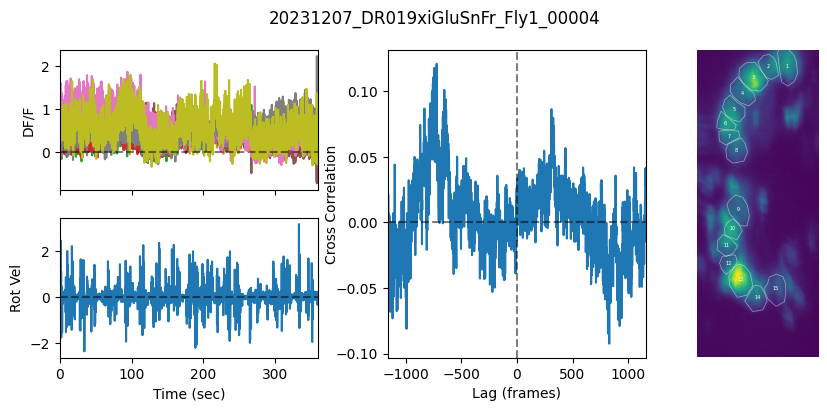

In [547]:
mosaic = [['img', '.', 'corr', 'rois'],
          ['bhv', '.', 'corr', 'rois']]
plots = ['img', 'bhv', 'corr']
fig, axd = plt.subplot_mosaic(mosaic, figsize=(10, 4), width_ratios=[1,0.01,1,0.6])

# Plot DF/F and Rot Vel
for i in range(get_num_rois(expDf)):
    axd['img'].plot(expDf['posTime'], expDf[f'roi{i}'])
axd['bhv'].plot(expDf['posTime'], expDf['vRfilt'])

# Cross correlation
a = expDf['roi0']
v = expDf['vRfilt']
lags = range(-1*len(a)//2, len(a)//2+1)
cross_correlation = correlate_with_lag(a, v, lags)
print(cross_correlation)
axd['corr'].plot(lags, cross_correlation)
# Add vertical line at x=0
axd['corr'].axvline(x=0, color='black', linestyle='--', zorder=2, alpha=0.5)

# Plot horizonal line at y=0
for plot in plots:
    axd[plot].axhline(y=0, color='black', linestyle='--', zorder=2, alpha=0.5)

# Set xlim
for plot in ['img', 'bhv']:
    axd[plot].set_xlim([round(expDf.iloc[0]['posTime']), expDf.iloc[-1]['posTime']])
axd['corr'].set_xlim([lags[0], lags[-1]])

# axd['corr'].set_xticklabels([ frame * expDf['posTime'].diff().mean() for frame in axd['corr'].get_xticks()])
# xticks = [lag for lag in np.arange(-len(a)//2, len(a)//2+1)*fm_interval if round(lag, 0)%20 ==0]
# xticklabels = [f'{tick*fm_interval:3.0f}' for tick in xticks]
# axd['corr'].set_xticks(xticks, xticklabels)

# Plot rois
plot_roi(exptDat, axd['rois'], title="")


axd['img'].set_xticklabels([])

axd['img'].set_ylabel("DF/F")
axd['bhv'].set_ylabel("Rot Vel")
axd['bhv'].set_xlabel("Time (sec)")
axd['corr'].set_ylabel("Cross Correlation", labelpad=-2)
axd['corr'].set_xlabel("Lag (frames)")

fig.suptitle(exptDat.get('trialName'))

# Print peak correlation
peak_corr_lag = lags[np.argmax(cross_correlation)]
print(f'Peak correlation at {peak_corr_lag:+} frames of lag ({peak_corr_lag * fm_interval:+} seconds)')

fig.savefig(Path(OUTPUT_FOLDER, exptDat['trialName']).with_suffix(".png"), dpi=600)

### Head direction plot

In [548]:
expDf.keys()

Index(['roi0', 'roi1', 'roi2', 'roi3', 'roi4', 'roi5', 'roi6', 'roi7', 'roi8',
       'roi9', 'roi10', 'roi11', 'roi12', 'roi13', 'roi14', 'posTime', 'frame',
       'x', 'y', 'angle', 'vT', 'vR', 'vTfilt', 'vRfilt', 's', 'ds', 'dx',
       'dy', 'flight', 'clipped'],
      dtype='object')

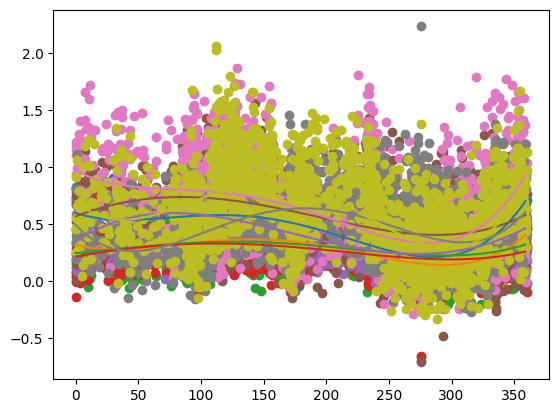

In [549]:
# plt.scatter(expDf['angle'], expDf['vR'])
# plt.scatter(expDf['angle'], expDf['roi0'])
# plt.scatter(expDf['angle'], expDf['roi1'])
roi = 0
for roi in range(15):
    x = expDf['angle']
    y = expDf[f'roi{roi}']
    poly_coefs = np.polyfit(x, y, 4)
    p = np.poly1d(poly_coefs)

    plt.scatter(expDf['angle'], expDf[f'roi{roi}'])
    plt.plot([p(point) for point in np.linspace(0, 360,360)])

    # for i in range(15):
    #     plt.scatter(expDf['angle'], expDf[f'roi{i}'])

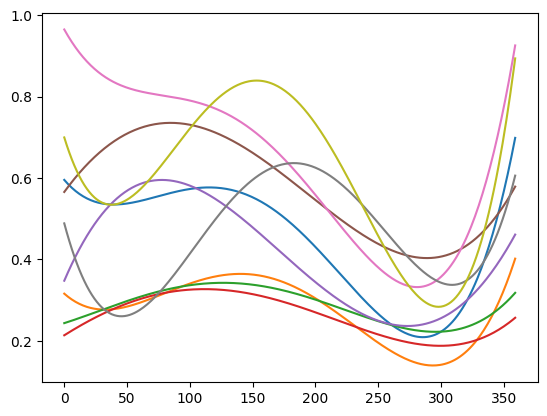

In [550]:
# plt.scatter(expDf['angle'], expDf['vR'])
# plt.scatter(expDf['angle'], expDf['roi0'])
# plt.scatter(expDf['angle'], expDf['roi1'])
roi = 0
for roi in range(15):
    x = expDf['angle']
    y = expDf[f'roi{roi}']
    poly_coefs = np.polyfit(x, y, 4)
    p = np.poly1d(poly_coefs)

    # plt.scatter(expDf['angle'], expDf[f'roi{roi}'])
    plt.plot([p(point) for point in np.linspace(0, 360,360)])

    # for i in range(15):
    #     plt.scatter(expDf['angle'], expDf[f'roi{i}'])

## Activity Bump Cross Section

Create heatmap of roi flor over time. (like glupuff).

at each timepoint calculate the circular mean and circular r. If the circular r (pointiness of bump) is large enough (~0.2-0.3) consider it a bump.

for each timepoint shift the bump to the same spot (0). 

Then you can average over time, to look at a cross section of the bump.

This should fit nicely with a cos, and have a full width at half max height of pi/2.

### Split the PB

And run the analysis on the upper and lower arm

In [551]:
# Last roi in first half
pb_midpoint = 8 - 1 # sub 1 since it indexes at 0

In [552]:
upper_deltaf = exptDat['DF_G'][:,:pb_midpoint+1] # Add one to include midpoint in first half
lower_deltaf = exptDat['DF_G'][:,pb_midpoint+1:] # Add one to exclude midpoint from last half

In [553]:
lower_deltaf.shape

(2350, 7)

### Heatmap

In [554]:
exptDat.keys()

dict_keys(['trialName', 'fpv', 'meanMIP_G', 'ROIOutlines', 'allROIs', 'rawF_G', 'DF_G', 'expDf'])

In [555]:
expDf

,roi0,roi1,roi2,roi3,roi4,roi5,roi6,roi7,roi8,roi9,...,vT,vR,vTfilt,vRfilt,s,ds,dx,dy,flight,clipped
0,0.814344,0.725667,0.166497,-0.144794,0.199057,0.454983,1.215122,0.236813,0.255047,NaN,...,0.035489,0.091919,0.608693,0.508432,0.000436,0.000436,0.000345,-0.000268,0.0,0.0
1,0.671801,0.223545,0.216548,0.021791,0.414937,0.502743,0.985852,0.427911,0.658517,NaN,...,0.329879,-0.120483,0.288276,-0.011478,0.004924,0.004488,-0.001636,-0.000725,0.0,0.0
2,0.708703,0.171956,-0.023121,-0.096136,0.509204,0.759751,1.037323,0.411921,1.128446,NaN,...,1.027507,0.873111,0.638909,0.472705,0.018986,0.014062,0.000401,0.001447,0.0,0.0
3,0.693227,0.327904,0.079298,0.072838,0.584462,0.666486,0.937164,0.235004,0.457898,NaN,...,0.513855,0.019104,0.488927,0.035267,0.030041,0.011054,0.000496,-0.000331,0.0,0.0
4,0.676137,0.117157,-0.008606,0.053550,0.244129,0.804605,1.161300,0.189748,0.915428,NaN,...,0.519853,0.888478,0.464436,-0.159751,0.039833,0.009792,-0.000373,0.000321,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2317,0.164295,0.138319,0.263062,0.131673,-0.037635,0.048172,0.166889,0.327039,0.189579,NaN,...,0.429574,-0.223446,0.299267,-0.021566,31.781603,0.019170,-0.000677,-0.000174,0.0,0.0
2318,-0.075184,-0.030982,0.315783,0.188699,0.038609,0.151170,0.083062,0.791692,0.115432,NaN,...,0.862678,0.368904,0.860205,-0.159926,31.803103,0.021500,0.000251,0.000250,0.0,0.0
2319,-0.106421,0.065873,0.129064,0.213831,0.049721,0.227134,0.144123,0.552213,0.029133,NaN,...,0.212791,0.319134,0.432499,-0.229006,31.817607,0.014504,-0.000622,0.000347,0.0,0.0
2320,-0.105377,0.176317,0.199688,0.187390,0.054493,-0.127669,-0.036460,0.870531,-0.276383,NaN,...,0.142511,-0.213890,0.331598,-0.101597,31.832087,0.014480,0.002085,-0.000713,0.0,0.0


In [556]:
def plot_heatmap(flor, axes=None, aspect=64, plot_cbar=True):
    if axes is None: 
        fig = plt.figure()
        ax = fig.add_subplot()
    else:
        ax = axes
        fig = axes.get_figure()

    im = ax.imshow(flor.T, aspect=aspect, interpolation='none', norm=CenteredNorm(), cmap='PiYG')
    ax.invert_yaxis()

    if plot_cbar:
        cbar = fig.colorbar(im, ax=ax, shrink=0.5)
        clim = [np.min(flor), np.max(flor)]
        # cbar.ax.set_ylim(clim)
        cbar.set_ticks([clim[0],clim[1]])

    if axes is not None:
        return
    else:
        return fig, ax

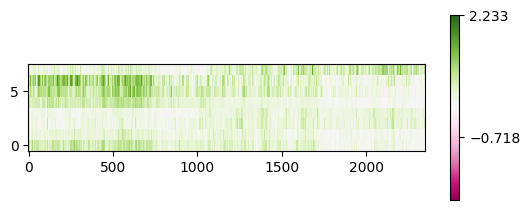

In [557]:
plot_heatmap(upper_deltaf, aspect=64)
pass

In [558]:
# try:
#     plot_heatmap(lower_deltaf)
# except ValueError:
#     print('error')

### Calculate the circular mean and r

In [559]:
import scipy.signal
#scipy.signal.peak_widths
#   Full width at half max

In [560]:
def get_roi_angles(num_rois):
    """Given the number of rois in one PB arm return a list sequentially assigning each roi to an angle

    Args:
        num_rois (int): number of rois in one PB arm (or in full EB)

    Returns:
        NDArray: Returns a list where at index i it has the angle for ROI i. 
    """
    return np.linspace(0,(2*np.pi),num_rois, endpoint=False)

def angle_roi_to_radians(roi_angle, low=0, high=8):
    return roi_angle/(high-low) * 2*np.pi

def angle_radians_to_roi(rad_angle, num_roi):
    roi_angle = rad_angle/(2*np.pi) * num_roi
    return roi_angle

def get_mean_roi(roi_weights, precise=False):
    num_rois = len(roi_weights)
    angles = get_roi_angles(num_rois)
    circ_mean_rad = pingouin.circ_mean(angles=angles, w=roi_weights)
    if circ_mean_rad < 0:
        circ_mean_rad += 2*np.pi
    roi_angle = angle_radians_to_roi(circ_mean_rad, num_rois)
    if not precise:
        roi_angle = round(roi_angle)
    return roi_angle

def get_mean_rois(deltaf_df, precise=False):
    num_frames, num_rois = deltaf_df.shape
    angles = np.repeat(np.expand_dims(get_roi_angles(num_rois), axis=0), num_frames, axis=0)
    circ_mean_rad = pingouin.circ_mean(angles=angles, w=deltaf_df, axis=1)
    # convert range -pi to pi into 0 to 2pi
    mask = (circ_mean_rad<0)
    circ_mean_rad[mask] += 2*np.pi

    roi_angle = angle_radians_to_roi(circ_mean_rad, num_rois)
    if not precise:
        roi_angle = np.round(roi_angle).astype(np.int32)
    return roi_angle

def get_circ_r(roi_weights):
    num_rois = len(roi_weights)
    angles = get_roi_angles(num_rois)
    return pingouin.circ_r(angles=angles, w=roi_weights)

def get_circ_rs(deltaf_df):
    num_frames, num_rois = deltaf_df.shape
    angles = np.repeat(np.expand_dims(get_roi_angles(num_rois), axis=0), num_frames, axis=0)
    return pingouin.circ_r(angles=angles, w=deltaf_df, axis=1)

def filter_mean_rois(mean_rois, circ_rs, min_r=0.15):
    # in place change
    if np.issubdtype(mean_rois.dtype , np.integer):
        empty_value = -1
    else:
        empty_value = np.nan
    
    mask = (circ_rs <  min_r)
    mean_rois[mask] = empty_value
    return mean_rois

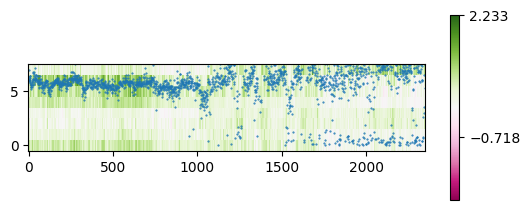

In [561]:
fig, ax = plt.subplots()

mean_rois = get_mean_rois(upper_deltaf, precise=True)
circ_rs = get_circ_rs(upper_deltaf)

mask = (circ_rs <  0.15)
mean_rois[mask] = None

ax.plot(mean_rois, lw=0, marker='o', ms=0.5)

plot_heatmap(upper_deltaf, axes=ax, aspect=64)

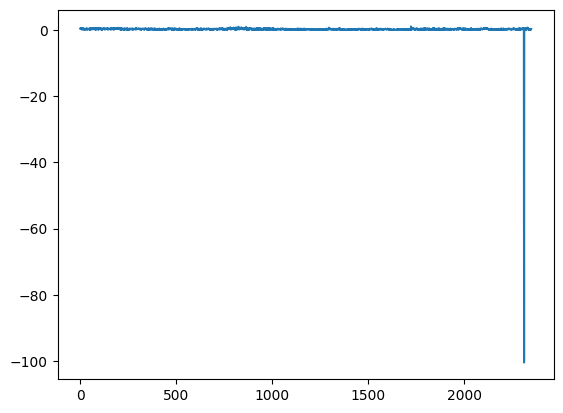

In [562]:
plt.plot(get_circ_rs(upper_deltaf))

In [563]:
# fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
# ax.plot(roi_angles,upper_deltaf[410])

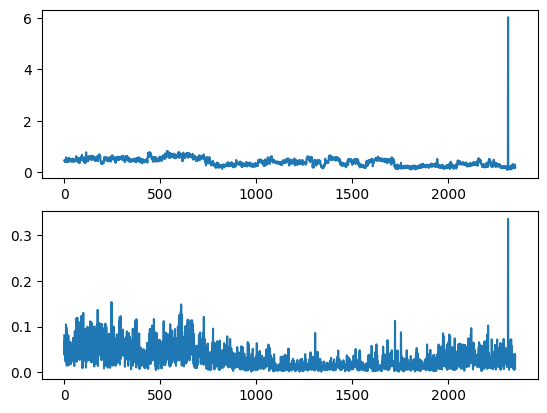

In [564]:
# Pick a random frame to calculate circ mean at
fig, axs = plt.subplots(2, 1)
axs[0].plot(scipy.stats.circmean(upper_deltaf, axis=1))
axs[1].plot(scipy.stats.circvar(upper_deltaf, axis=1))


### Not sure what im doing.
# I think I need to input angles into the circmean function
# so what is being plotted right now is nonsense
# 

### Align bumps

In [565]:
# https://stackoverflow.com/questions/40359940/numpy-roll-vertical-in-2d-array

# Roll with a negative shift:

# x2[:, 0] = np.roll(x2[:, 0], -2)

In [566]:
def align_bumps(deltaf_df, mean_rois=None, min_r = 0, offset=0):
    aligned_bumps = deltaf_df.copy()

    if mean_rois is None:
        mean_rois = get_mean_rois(aligned_bumps, precise=False)

    if min_r > 0:
        circ_rs = get_circ_rs(aligned_bumps)
        filter_mean_rois(mean_rois, circ_rs)

    for frame, mean_roi in enumerate(mean_rois):
        roll_amount = -1 * mean_roi + offset
        aligned_bumps[frame, :] = np.roll(aligned_bumps[frame, :], roll_amount)

    return aligned_bumps

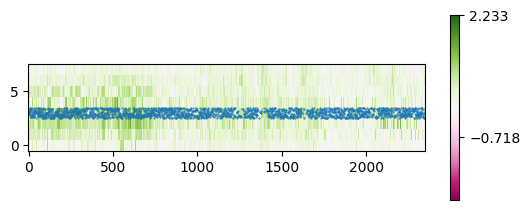

In [567]:

aligned_bumps = align_bumps(upper_deltaf, min_r = 0.15, offset=3)
# aligned_bumps = align_bumps(upper_deltaf)

aligned_bumps

fig, ax = plt.subplots()

mean_rois = get_mean_rois(aligned_bumps, precise=True)
circ_rs = get_circ_rs(aligned_bumps)

mask = (circ_rs <  0.15)
mean_rois[mask] = None

ax.plot(mean_rois, lw=0, marker='o', ms=0.5)

plot_heatmap(aligned_bumps, axes=ax, aspect=64)

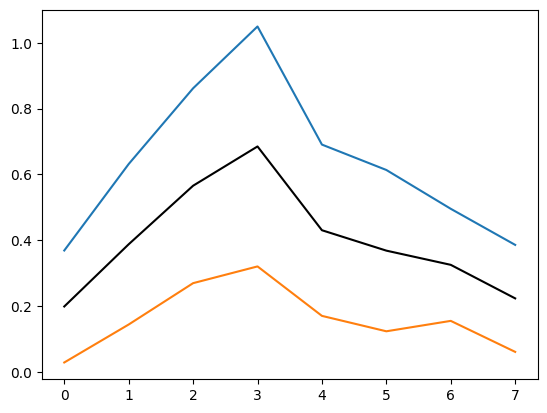

In [568]:
plt.plot(np.mean(aligned_bumps, axis=0), color='black')

plt.plot(np.mean(aligned_bumps, axis=0) + np.std(aligned_bumps, axis=0))
plt.plot(np.mean(aligned_bumps, axis=0) - np.std(aligned_bumps, axis=0))


## Create and save all plots for list of trials.

### Max Intensity Projection

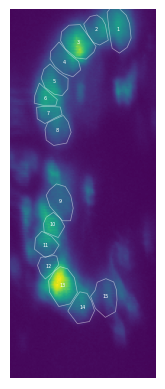

In [569]:
ax = plt.subplot()
plot_roi(exptDat, ax, title="")

### DF/F over time

(<Figure size 640x480 with 2 Axes>, <Axes: >)

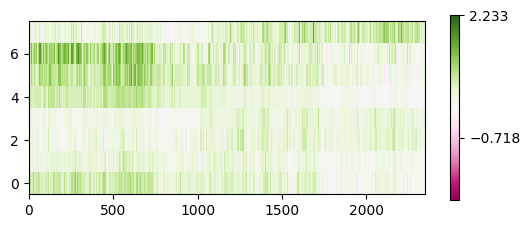

In [570]:
plot_heatmap(upper_deltaf, aspect=128)

### Tuning Curve

In [571]:
def plot_tuning_curves(expDf, ax, bot_roi=0, top_roi=7, scatter=True, fit=True, color=None):
    for roi in range(bot_roi, top_roi+1):
        x = expDf['angle']
        y = expDf[f'roi{roi}']
        poly_coefs = np.polyfit(x, y, 4)
        p = np.poly1d(poly_coefs)

        if scatter:
            ax.scatter(expDf['angle'], expDf[f'roi{roi}'])
        if fit:
            ax.plot([p(point) for point in np.linspace(0, 360,360)], color= color)
    
    # return ax

#### Single ROI tuning curve

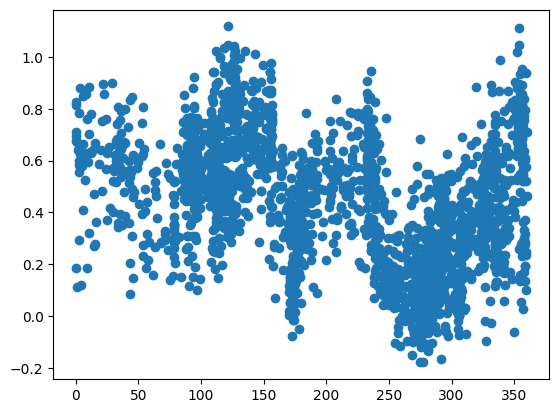

In [572]:
ax = plt.subplot()
plot_tuning_curves(expDf, ax, bot_roi=0, top_roi=0, fit=False)


#### With fit

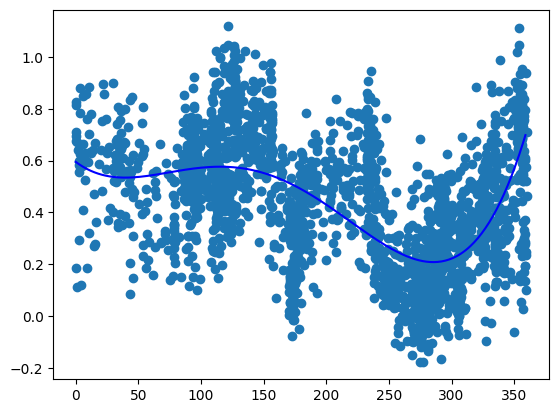

In [573]:
ax = plt.subplot()
plot_tuning_curves(expDf, ax, bot_roi=0, top_roi=0, color='b')

#### All the ROIs

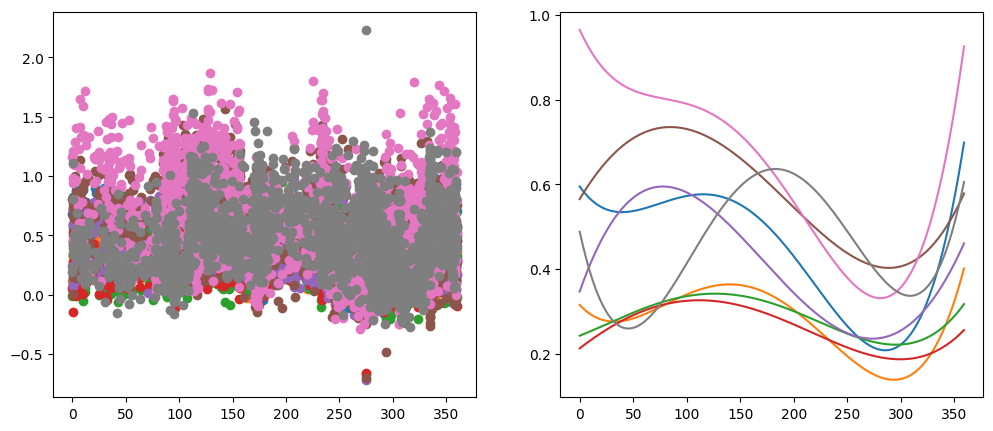

In [574]:
fig, axs = plt.subplots(1, 2, figsize=(12,5))
plot_tuning_curves(expDf, axs[0], bot_roi=0, top_roi=7, fit=False)
plot_tuning_curves(expDf, axs[1], bot_roi=0, top_roi=7, scatter=False)

### Estimate Bump Peak

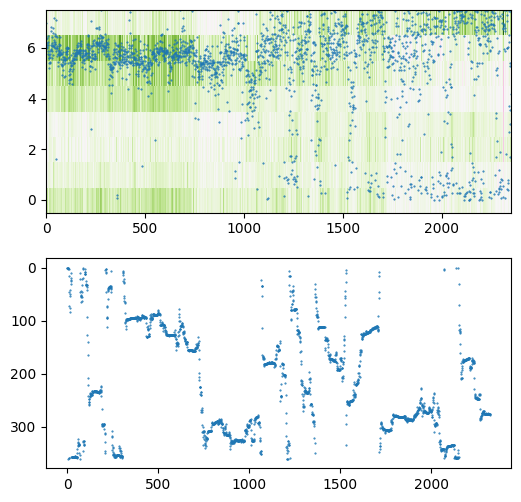

In [575]:
fig, axs = plt.subplots(2, 1 , figsize=(6,6))

mean_rois = get_mean_rois(upper_deltaf, precise=True)
circ_rs = get_circ_rs(upper_deltaf)

# mask = (circ_rs <  0.15)
# mean_rois[mask] = None

axs[0].plot(mean_rois, lw=0, marker='o', ms=0.5)

plot_heatmap(upper_deltaf, axes=axs[0], aspect=128, plot_cbar=False)


axs[1].plot(expDf['angle'], lw=0, marker='o', ms=0.5)

axs[1].invert_yaxis()

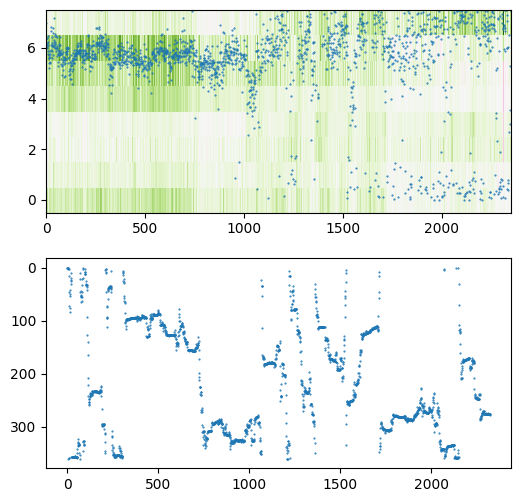

In [576]:
fig, axs = plt.subplots(2, 1 , figsize=(6,6))

mean_rois = get_mean_rois(upper_deltaf, precise=True)
circ_rs = get_circ_rs(upper_deltaf)

mask = (circ_rs <  0.15)
mean_rois[mask] = None

axs[0].plot(mean_rois, lw=0, marker='o', ms=0.5)

plot_heatmap(upper_deltaf, axes=axs[0], aspect=128, plot_cbar=False)


axs[1].plot(expDf['angle'], lw=0, marker='o', ms=0.5)

axs[1].invert_yaxis()

### Align the bump peaks

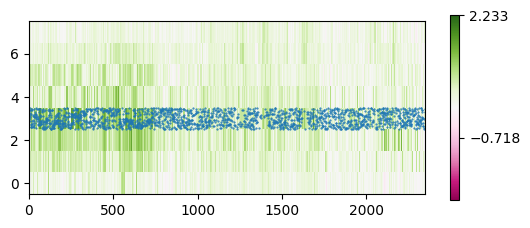

In [577]:

aligned_bumps = align_bumps(upper_deltaf, min_r = 0.15, offset=3)
# aligned_bumps = align_bumps(upper_deltaf)

aligned_bumps

fig, ax = plt.subplots()

mean_rois = get_mean_rois(aligned_bumps, precise=True)
circ_rs = get_circ_rs(aligned_bumps)

mask = (circ_rs <  0.15)
mean_rois[mask] = None

ax.plot(mean_rois, lw=0, marker='o', ms=0.5)

plot_heatmap(aligned_bumps, axes=ax, aspect=128)

### Average Bump

<ErrorbarContainer object of 3 artists>

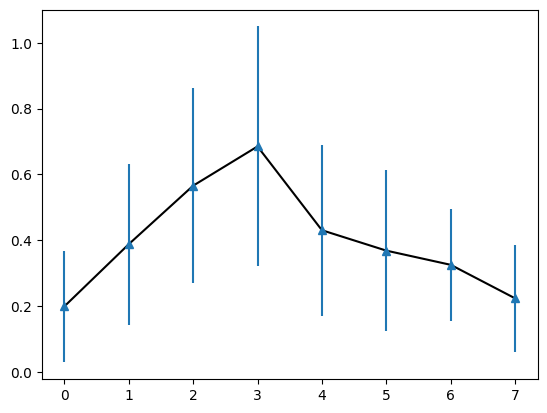

In [578]:
plt.plot(np.mean(aligned_bumps, axis=0), color='black')

# plt.plot(np.mean(aligned_bumps, axis=0) + np.std(aligned_bumps, axis=0))
# plt.plot(np.mean(aligned_bumps, axis=0) - np.std(aligned_bumps, axis=0))

plt.errorbar(np.arange(8), np.mean(aligned_bumps, axis=0), np.std(aligned_bumps, axis=0), linestyle='None', marker='^')
